# Unified Data Fusion Workflow

This notebook runs a multi-method workflow, a seismic line constraining an ERT inversion, from a request written in plain language through `BaseAgent.run_unified_agent_workflow()`.

## Data Fusion Workflow

Integrate multiple geophysical methods for comprehensive subsurface characterization:
- **Seismic** → velocity structure
- **ERT** → structure-constrained resistivity inversion
- **Petrophysics** → water content with uncertainty

## How It Works

```python
# 1. Describe the task in plain language
user_request = "Use seismic at threshold 1000 m/s to constrain ERT..."

# 2. A language model turns the request into a workflow configuration
config = context_agent.parse_request(user_request)
config["user_request"] = user_request   # the controller reads the request too

# 3. The workflow controller runs it, choosing each step from what the run holds
results, plan, interpretation, files = BaseAgent.run_unified_agent_workflow(
    config, api_key, llm_model, llm_provider, output_dir
)

# 4. Multi-method results, the steps that ran and the report
```

`run_unified_agent_workflow()` hands the configuration to the workflow controller in `PyHydroGeophysX.agents.runtime`. Before each step the controller lists the tools whose inputs the run already holds (load the surveys, invert them, evaluate the inversion, convert to water content, fetch climate data, invert a seismic line, derive structural constraints, fuse methods, write the report), picks one, and reads its result before picking the next. With an API key the language model picks; without one, the controller takes the runnable tools in dependency order. The execution plan it returns lists the steps that ran, each with the reason it was chosen.

With a seismic line beside one ERT survey, the controller offers the structural constraint: it re-inverts the survey with the velocity interface built into the mesh, and the conversion to water content waits for that model.

## Key Features

✅ **Structure Constraints**: The seismic interface bounds the ERT inversion
✅ **Layer-Specific**: Different petrophysical parameters above and below the interface
✅ **Uncertainty**: Monte Carlo analysis for water content

---

## 1. Setup and Imports

In [1]:
import json
import os
from pathlib import Path

import numpy as np

from PyHydroGeophysX.agents import BaseAgent, ContextInputAgent

# Where this notebook writes its results
default_output_dir = Path('results/unified_workflow/example3')
default_output_dir.mkdir(parents=True, exist_ok=True)

print("✓ PyHydroGeophysX agents imported")
print(f"✓ Output directory: {default_output_dir}")

✓ PyHydroGeophysX agents imported
✓ Output directory: results\unified_workflow\example3


## 2. Configure the Language Model

The request is parsed by a language model. Set `OPENAI_API_KEY` to parse it live. Without a key the notebook uses the configuration the parser produced for this request in the reference run, so it still runs, on the same configuration as the reference run; the workflow controller then takes the runnable steps in dependency order instead of asking the model.

In [2]:
# Configure API (set OPENAI_API_KEY in the environment, or change the provider)
llm_provider = 'openai'  # Options: 'openai', 'gemini', 'claude'
llm_model = 'gpt-4o-mini'
api_key = os.getenv('OPENAI_API_KEY')

if api_key:
    # Natural-language parsing of the request
    context_agent = ContextInputAgent(api_key=api_key, model=llm_model, llm_provider=llm_provider)
    print(f"✓ Using {llm_provider} with model {llm_model}")
else:
    context_agent = None
    print("ℹ️  No API key: the notebook uses the recorded configuration, and the")
    print("   workflow controller takes the runnable steps in dependency order")

ℹ️  No API key: the notebook uses the recorded configuration, and the
   workflow controller takes the runnable steps in dependency order


## 3. Seismic-Constrained ERT Example

This example uses:
- **Field seismic** from `data/Seismic/srtfieldline2.dat`
- **Field ERT** from `data/ERT/Bert/fielddataline2.dat`
- **Velocity threshold** at 1000 m/s for the boundary between regolith and fractured bedrock
- **Layer-specific petrophysics** with Monte Carlo uncertainty

The controller inverts and evaluates the ERT line, inverts the seismic line, re-inverts the ERT with the 1000 m/s interface built into the mesh, converts that model to water content with separate parameters above and below the interface, fuses the methods, and writes the report.

In [3]:
user_request = """I need to characterize subsurface water content using a multi-method approach with field data:

1. First, use field seismic refraction data to identify the boundary between regolith and fractured bedrock.
   The seismic data is in 'data/Seismic/srtfieldline2.dat' (BERT format)
   Use a velocity threshold of 1000 m/s to extract the interface for regolith and fractured bedrock.

2. Then, use this seismic structure to constrain ERT inversion with field ERT data.
   The ERT data is in 'data/ERT/Bert/fielddataline2.dat' (BERT format).
   Apply moderate regularization (lambda=20) since we have structural constraints and field data.

3. Finally, convert the resistivity model to water content using layer-specific petrophysical parameters.
   Use Monte Carlo uncertainty analysis with 100 realizations.
   Account for different petrophysical properties in regolith vs fractured bedrock layers:
   - Regolith layer: rho_sat (50-250 Ωm), n (1.3-2.2), porosity (0.25-0.5)
   - Fractured bedrock layer: rho_sat (165-350 Ωm), n (2.0-2.2), porosity (0.2-0.3)

This is a full structure-constrained hydrogeophysical workflow for field data analysis."""

# The configuration the parser produced for this request in the reference run.
# It is used when no API key is set, so the notebook still runs on that configuration.
RECORDED_CONFIG = json.loads(r"""
{
  "data_file": "data/ERT/Bert/fielddataline2.dat",
  "project_dir": "data/ERT/Bert",
  "instrument": "BERT",
  "crs": "local",
  "inversion_mode": "standard",
  "inversion_params": {
    "lambda": 20,
    "max_iterations": 10,
    "method": "cgls",
    "use_gpu": false
  },
  "petrophysical_parameters": {
    "regolith": {
      "rho_sat": [
        50,
        250
      ],
      "porosity": [
        0.25,
        0.5
      ],
      "n": [
        1.3,
        2.2
      ]
    },
    "fractured_bedrock": {
      "rho_sat": [
        165,
        350
      ],
      "porosity": [
        0.2,
        0.3
      ],
      "n": [
        2.0,
        2.2
      ]
    }
  },
  "fusion_pattern": "full_integration",
  "methods": [
    "seismic",
    "ert",
    "petrophysics"
  ],
  "seismic_file": "data/Seismic/srtfieldline2.dat",
  "ert_file": "data/ERT/Bert/fielddataline2.dat",
  "velocity_threshold": 1000,
  "seismic_params": {
    "lam": 50,
    "zWeight": 0.2,
    "vTop": 500,
    "vBottom": 5000
  },
  "ert_params": {
    "lambda": 20,
    "max_iterations": 20,
    "limits": [
      1.0,
      10000.0
    ]
  },
  "n_realizations": 100,
  "layer_params": {
    "regolith": {
      "rho_sat_range": [
        50,
        250
      ],
      "n_range": [
        1.3,
        2.2
      ],
      "porosity_range": [
        0.25,
        0.5
      ]
    },
    "fractured_bedrock": {
      "rho_sat_range": [
        165,
        350
      ],
      "n_range": [
        2.0,
        2.2
      ],
      "porosity_range": [
        0.2,
        0.3
      ]
    }
  },
  "use_climate": false,
  "use_seismic": false,
  "run_uncertainty": true,
  "petrophysical_params": {},
  "coverage_threshold": -1.0,
  "mesh_quality": 31,
  "mesh_params": {
    "paraDepth": 22.0,
    "paraDX": 0.5,
    "paraMaxCellSize": 5
  },
  "output_dir": "results/data_fusion"
}
""")

print("=" * 70)
print("USER REQUEST:")
print(user_request)
print("=" * 70)

if context_agent is not None:
    print("\n🤖 Parsing request...")
    config = context_agent.parse_request(user_request)
else:
    config = json.loads(json.dumps(RECORDED_CONFIG))   # a fresh copy
    print("\nℹ️  Using the recorded configuration")
# The controller reads the request too: what it asks for, and the report quotes it
config["user_request"] = user_request
print(json.dumps({key: value for key, value in config.items() if key != "user_request"},
                 indent=2, default=str))

# The workflow controller chooses each step from the tools whose inputs exist
print("\n🚀 Running the workflow...")
output_dir = Path('results/unified_workflow/example3')
results, execution_plan, interpretation, report_files = BaseAgent.run_unified_agent_workflow(
    config, api_key, llm_model, llm_provider, output_dir
)

USER REQUEST:
I need to characterize subsurface water content using a multi-method approach with field data:

1. First, use field seismic refraction data to identify the boundary between regolith and fractured bedrock.
   The seismic data is in 'data/Seismic/srtfieldline2.dat' (BERT format)
   Use a velocity threshold of 1000 m/s to extract the interface for regolith and fractured bedrock.

2. Then, use this seismic structure to constrain ERT inversion with field ERT data.
   The ERT data is in 'data/ERT/Bert/fielddataline2.dat' (BERT format).
   Apply moderate regularization (lambda=20) since we have structural constraints and field data.

3. Finally, convert the resistivity model to water content using layer-specific petrophysical parameters.
   Use Monte Carlo uncertainty analysis with 100 realizations.
   Account for different petrophysical properties in regolith vs fractured bedrock layers:
   - Regolith layer: rho_sat (50-250 Ωm), n (1.3-2.2), porosity (0.25-0.5)
   - Fractured b

[PyHydroGeophysX] ResIPy is not installed; using this package's own readers. Install with: pip install "PyHydroGeophysX[ert]"
[PyHydroGeophysX] PyGIMLi loaded successfully


[PyHydroGeophysX] SimPEG loaded successfully (version 0.25.2)
[PyHydroGeophysX] Reading ERT data without ResIPy.
ResIPy is the recommended ERT reader: it covers more instrument formats than this package reads on its own.
    pip install "PyHydroGeophysX[ert]"        (or: pip install resipy)

If the install or the import fails:
  * a compiler or build error: ResIPy carries compiled solvers, and a cloud image or slim container often has no toolchain. Try 'pip install --only-binary :all: resipy', or build the environment from conda-forge.
  * an import error after a successful install: usually a NumPy or Python version mismatch. 'pip check' names the conflict.
  * no network: install it into the image ahead of time; the readers below need nothing extra and will keep working meanwhile.

Without ResIPy this package reads: ABEM-Lund, ARES, BERT, DAS-1, E4D, Lippmann, ResInv, Sting, Subsurface Insights. Any other format needs it.
[PyHydroGeophysX] Attempting to parse ERT data with BERT parser

[ert_loader] [INFO] Loading data from data\ERT\Bert\fielddataline2.dat (BERT format)
   Using source 'dev' error estimates (mean: 0.0129)
[ert_loader] [INFO] Loaded 72 electrodes, 936 measurements
[ert_loader] [INFO] Running quality control checks


26/09/26 - 10:19:15 - pyGIMLi - INFO - Cache <env>\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (3.5s x 16): <appdata>\pygimli\Cache\14655022930616347562


...

[inversion_evaluation] [INFO] Starting inversion quality evaluation
[inversion_evaluation] [INFO] Initial quality score: 30.0/100
[petrophysics] [INFO] Starting petrophysical conversion with uncertainty analysis
[petrophysics] [INFO] Processing 4358 cells, 1 time step(s)
[petrophysics] [INFO] Monte Carlo realizations: 100
[petrophysics] [INFO] Using 2 geological layers from the mesh markers (cells per layer: 2345, 2013).
[petrophysics] [INFO] Layer-specific parameters provided: ['regolith', 'fractured_bedrock']
[petrophysics] [INFO] Information level: high
[petrophysics] [INFO] Mapped 'regolith' to layer ID 2
[petrophysics] [INFO]   ρ_sat: 150.0 ± 50.0 Ωm
[petrophysics] [INFO]   n: 1.75 ± 0.23
[petrophysics] [INFO]   φ: 0.38 ± 0.06
[petrophysics] [INFO] Mapped 'fractured_bedrock' to layer ID 3
[petrophysics] [INFO]   ρ_sat: 257.5 ± 46.2 Ωm
[petrophysics] [INFO]   n: 2.10 ± 0.05
[petrophysics] [INFO]   φ: 0.25 ± 0.02
[petrophysics] [INFO] Starting Monte Carlo simulation...
[petrophysics

[report_generator] [INFO] Coverage threshold: -1.351 (kept 98.3% cells, deepest point 24.8 m, min target 24.7 m)
[report_generator] [INFO] Resistivity colormap: 49.7 to 557.1 ohm-m
[report_generator] [INFO] Vertical display span set to 24.8 m (min required 24.7 m)


[report_generator] [INFO] Saved resistivity model plot
[report_generator] [INFO] Water content colormap: 0.145 to 0.374


[report_generator] [INFO] Saved water content plot
[report_generator] [INFO] Uncertainty colormap: 0.0235 to 0.0750


[report_generator] [INFO] Saved water content uncertainty plot
[report_generator] [WARNING] markdown package not installed; skipping the PDF (the Markdown report is still written)
[report_generator] [INFO] Report saved to results\unified_workflow\example3\workflow_report.md


## 4. Results

The execution plan lists every step the controller took, with the reason it chose it, its status and its run time. The interpretation below it is the controller's own account of the run.

In [4]:
print("=" * 70)
print("STEPS THE CONTROLLER TOOK")
print("=" * 70)
for i, step in enumerate(execution_plan, 1):
    print(f"{i}. {step['step']} ({step['agent']}): {step['status']}, {step['seconds']:.0f} s")
    print(f"   why: {step['reason']}")

print(f"\nStatus: {results.get('status')}")
for warning in results.get('warnings', []):
    print(f"  ! {warning}")

evaluation = results.get('evaluation_results') or {}
fit = (evaluation.get('quality_metrics') or {}).get('data_fit') or {}
if fit.get('final_chi2') is not None:
    print(f"\nData fit: chi² = {fit['final_chi2']:.2f} (target 1)")

seismic = results.get('seismic_results') or {}
if seismic.get('velocity_range') is not None:
    vmin, vmax = seismic['velocity_range']
    print(f"\n📊 Seismic velocity: {vmin:.0f} to {vmax:.0f} m/s")
for threshold, line in (seismic.get('interfaces') or {}).items():
    print(f"   {threshold} m/s interface: {len(line['x'])} points, "
          f"depth {-np.max(line['z']):.1f} to {-np.min(line['z']):.1f} m")
wc = results.get('water_content_mean')
layers = results.get('cell_markers')
if wc is not None and layers is not None:
    wc = np.asarray(wc, dtype=float).ravel()
    wc_std = np.asarray(results.get('water_content_std'), dtype=float).ravel()
    layers = np.asarray(layers)
    names = list((config.get('layer_params') or {}).keys())
    print(f"Water content: {np.nanmin(wc):.3f} to {np.nanmax(wc):.3f}, "
          f"mean uncertainty {np.nanmean(wc_std):.3f}")
    for index, layer in enumerate(np.unique(layers)):
        name = names[index] if index < len(names) else f"layer {layer}"
        inside = layers == layer
        print(f"   {name} (marker {layer}, {inside.sum()} cells): "
              f"mean {np.nanmean(wc[inside]):.3f} ± {np.nanmean(wc_std[inside]):.3f}")

if report_files:
    print(f"\n📄 Report files:")
    for name, path in report_files.items():
        print(f"  - {name}: {path}")

print("\n" + "=" * 70)
print("INTERPRETATION")
print("=" * 70)
print(interpretation)

STEPS THE CONTROLLER TOOK
1. Load ERT data (ERTLoaderAgent): ok, 3 s
   why: next available step
2. Run ERT inversion (ERTInversionAgent): ok, 22 s
   why: next available step
3. Evaluate inversion quality (InversionEvaluationAgent): ok, 47 s
   why: next available step
4. Run seismic refraction inversion (SeismicAgent): ok, 11 s
   why: next available step
5. Extract structural constraints (StructureConstraintAgent): ok, 72 s
   why: next available step
6. Convert to water content (PetrophysicsAgent): ok, 0 s
   why: next available step
7. Fuse methods (DataFusionAgent): ok, 0 s
   why: next available step
8. Generate report (ReportAgent): ok, 1 s
   why: next available step

Status: success
  ! The exported model carries no layer markers: The cell markers do not describe geological structure (1356 markers for 1356 cells), so the section is treated as a single unit with one petrophysical parameter set. Supplying a layered model is what would let parameters vary with depth.
  ! Quality

### Figures

The report agent saves its figures beside the report; they are shown here.

resistivity


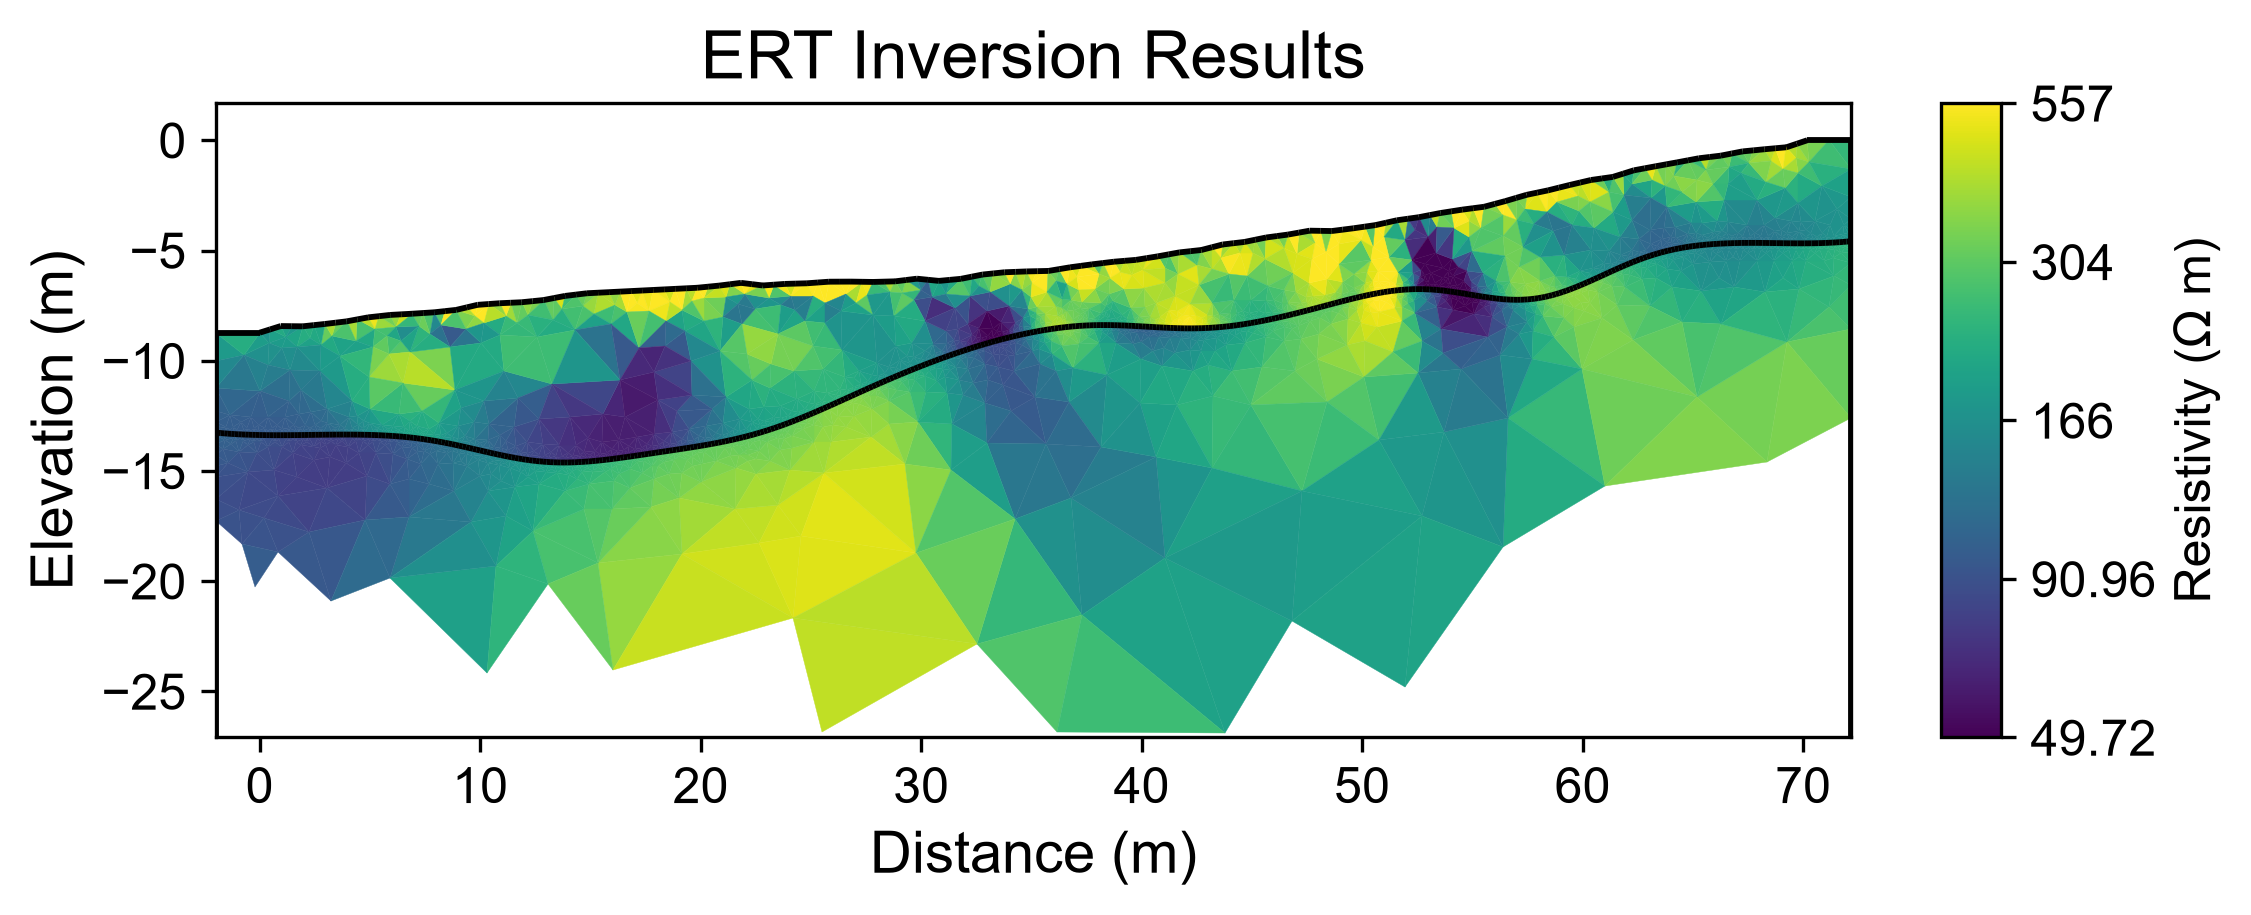

water content


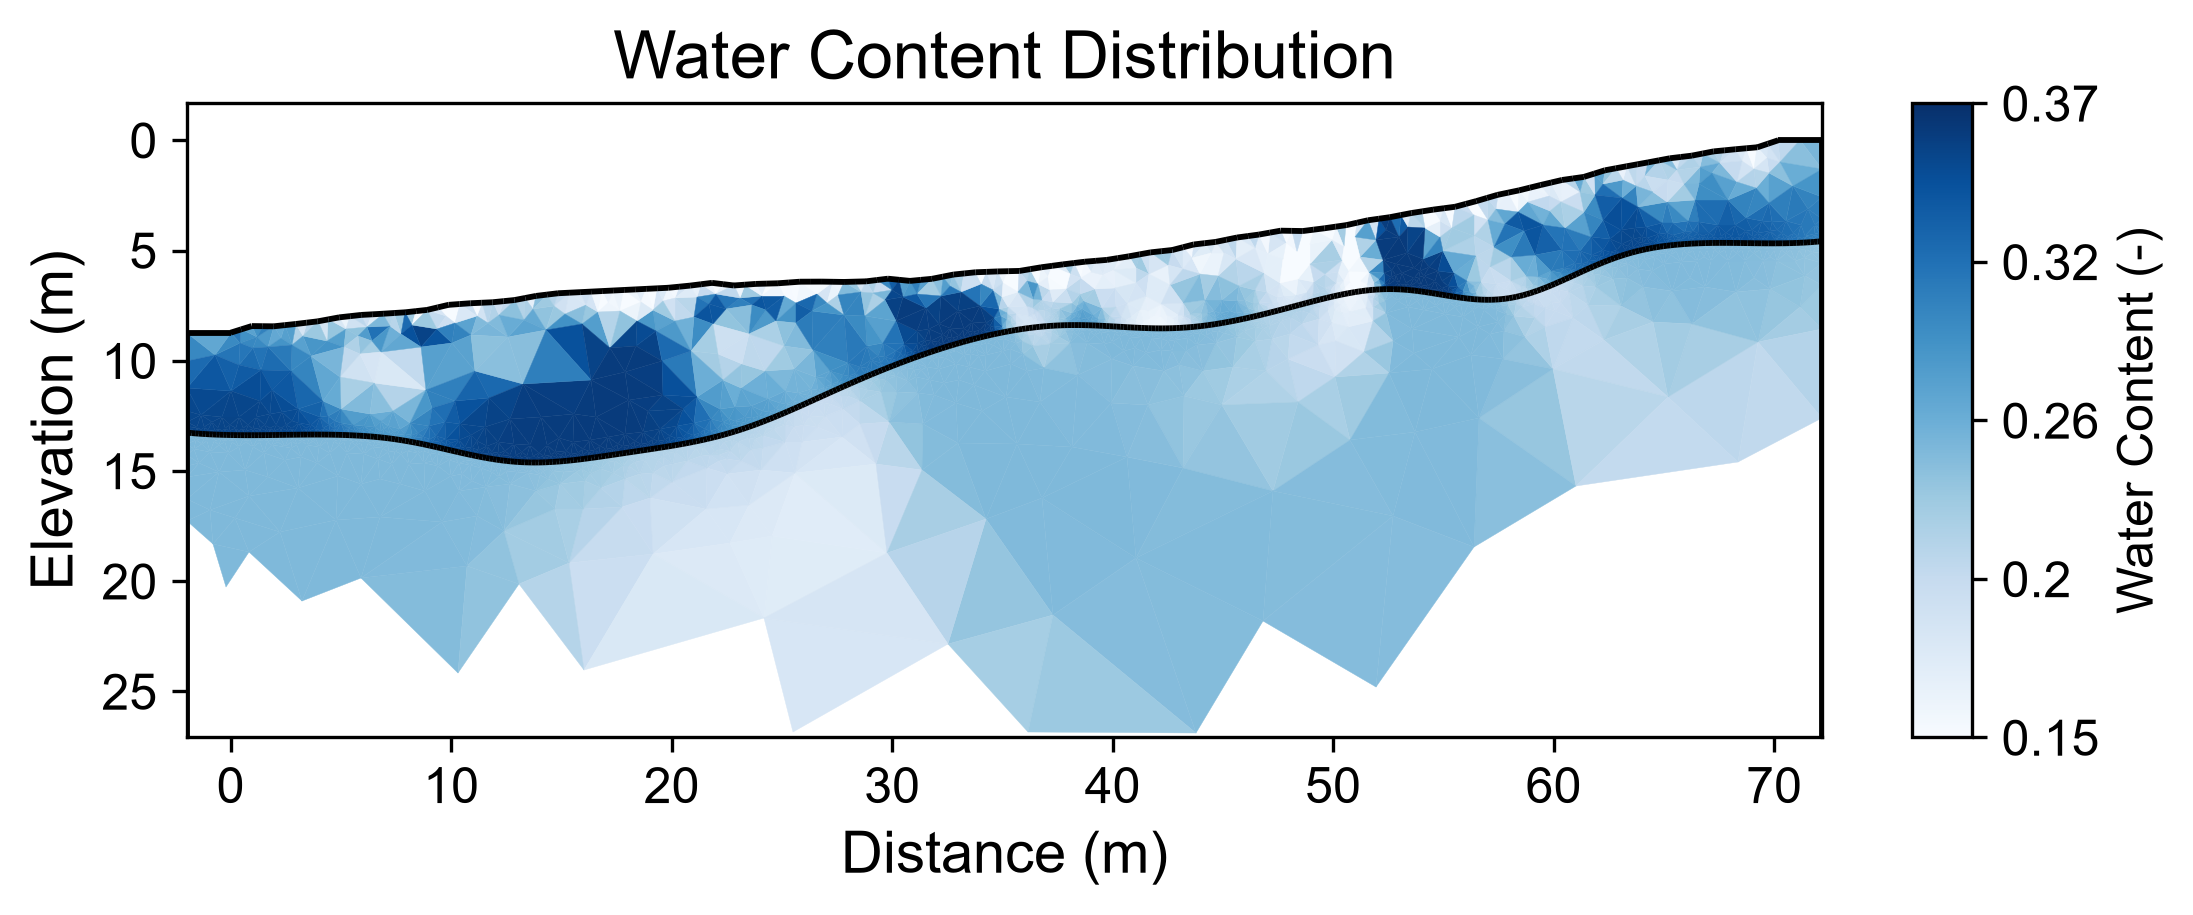

water content uncertainty


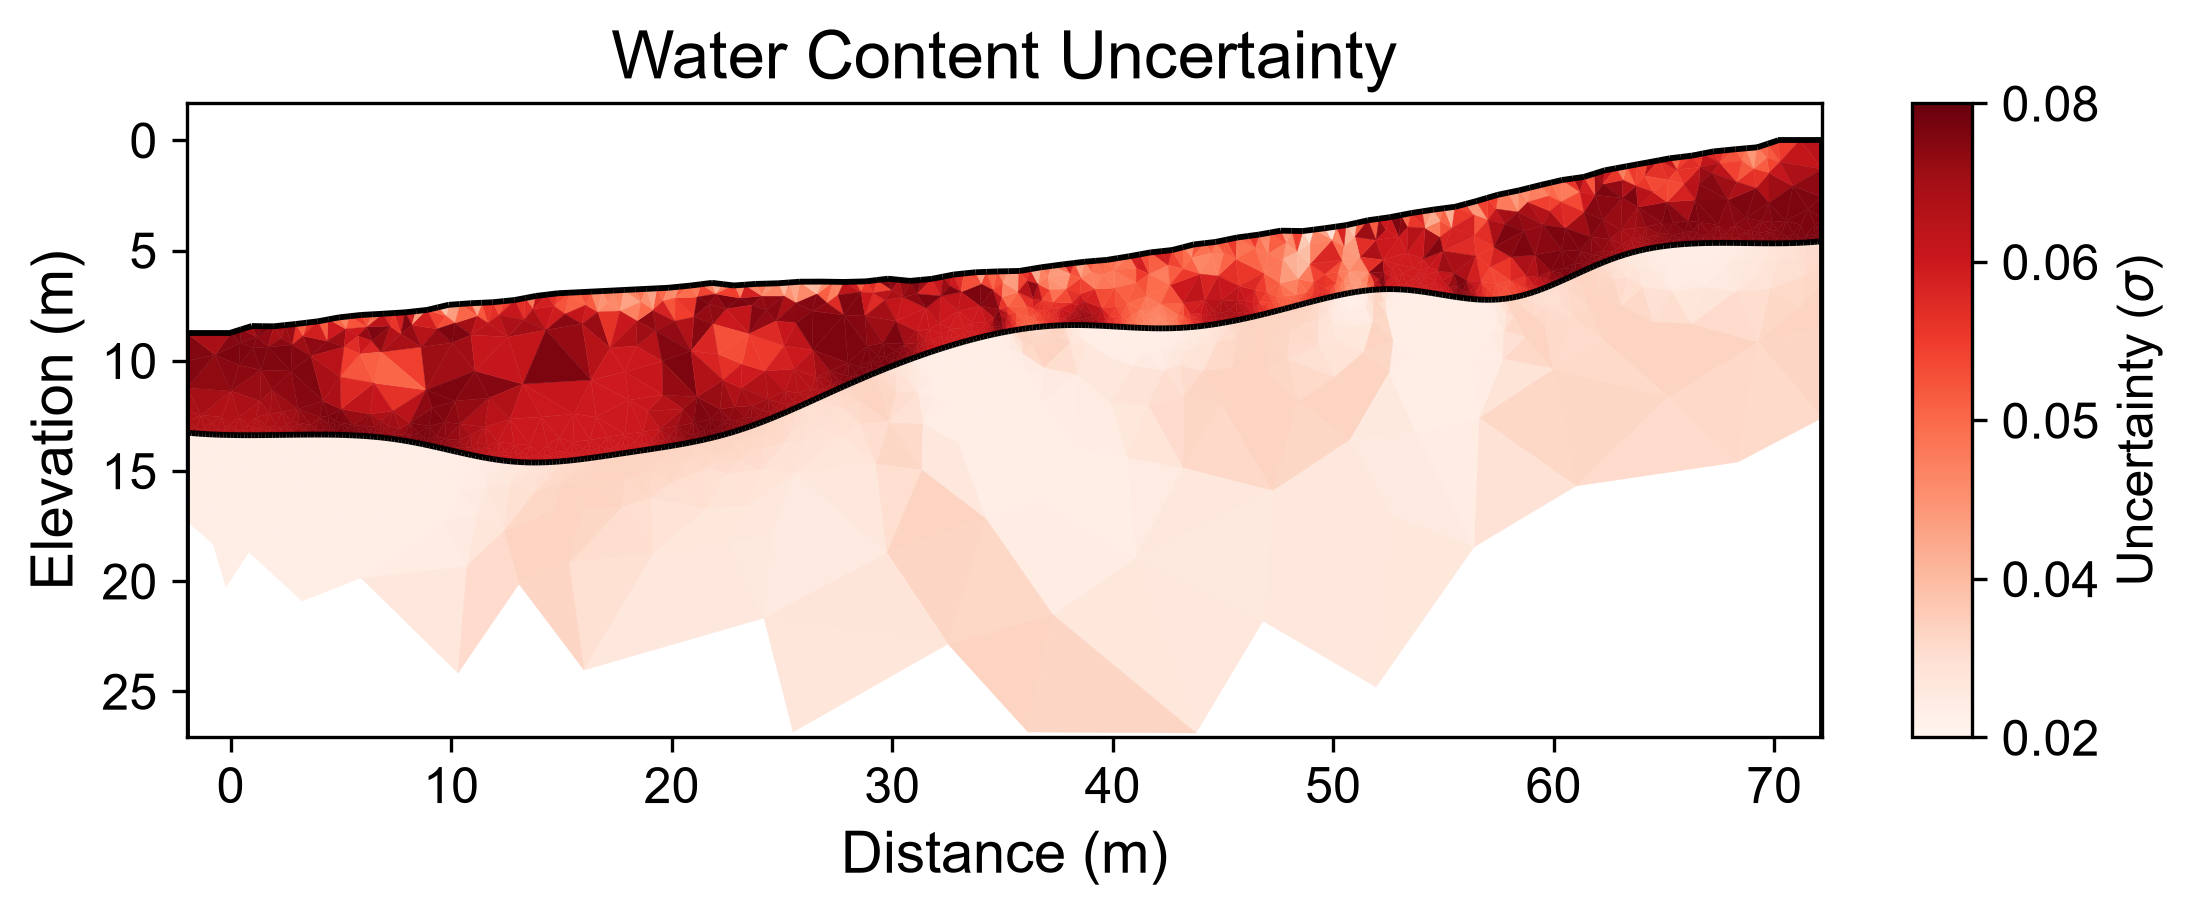

In [5]:
from IPython.display import Image, display

for name, path in (report_files or {}).items():
    if str(path).lower().endswith('.png') and Path(path).exists():
        print(name.replace('visualization_', '').replace('_', ' '))
        display(Image(filename=str(path)))

## Summary

- **One entry point**: `BaseAgent.run_unified_agent_workflow()` takes the parsed configuration of any request.
- **Steps chosen from the data**: a seismic line beside one ERT survey makes the controller offer the structural constraint, and the conversion to water content waits for the constrained model; the execution plan lists only the steps that ran.
- **Other requests, same call**: `Ex_Unified_Workflow_ex1` (one survey to water content) and `Ex_Unified_Workflow_ex2` (time-lapse with climate data) change only the request.
- **Step by step**: to approve each step before it runs, pass an approval function:

```python
from PyHydroGeophysX.agents.runtime.modes import step_by_step

def approve(step):
    return 'proceed' if input(f"Run '{step['label']}'? [y/n] ") == 'y' else 'stop'

BaseAgent.run_unified_agent_workflow(config, api_key, llm_model, llm_provider, output_dir,
                                     on_step=step_by_step(approve))
```

- **The previous pipeline**: set `PHGX_LEGACY_WORKFLOW=1` to run the fixed per-type pipeline the controller replaced.

### Next: Try the Streamlit Web App

For an interface without code, check out `app_geophysics_workflow.py`, a web UI where you can:
- Input natural language descriptions
- Upload data files
- Get results and reports automatically

Run with: `streamlit run app_geophysics_workflow.py`